## Read the data

In [34]:
import pandas as pd
import numpy as np


df = pd.read_csv("C:\\Users\\Dell\\Desktop\\Python_projects\\test project\\Project-DEPI\\resampled_15min_data.csv", index_col = 'Date')
df.head()

,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,apparent_power,power_factor,Energy_kWh,Energy_kWh_cummlative
Date,,,,,,,,,
16/12/2006,17:30:00,3.702,0.52,235.09,15.8,3.738342,0.990278,0.061700,0.520433
16/12/2006,17:45:00,7.706,0.00,230.98,33.2,7.706000,1.000000,0.128433,1.622333
16/12/2006,18:00:00,2.790,0.18,237.52,11.8,2.795800,0.997925,0.046500,2.580233
16/12/2006,18:15:00,4.598,0.10,234.25,21.4,4.599087,0.999764,0.076633,3.640633
16/12/2006,18:30:00,2.930,0.00,236.15,12.4,2.930000,1.000000,0.048833,4.554967


In [35]:
df.isna().any()

Time                     False
Global_active_power      False
Global_reactive_power    False
Voltage                  False
Global_intensity         False
apparent_power           False
power_factor             False
Energy_kWh               False
Energy_kWh_cummlative    False
dtype: bool

In [36]:
test_data = [
    {"Voltage": 234.4, "Global_intensity" : 20.3, "apparent_power" : 4.4177616419, "Energy_kWh" : 0.073213, "hour" : 6, "minutes" : 30, "pref_power_factor" : 0.94, "mean_power_factor_3" : 0.90}
]

In [37]:
df['Time'] = pd.to_datetime(df['Time'], format="%H:%M:%S")

df["hour"] = df['Time'].dt.hour
df["minutes"] = df['Time'].dt.minute


In [38]:
df['pref_power_factor'] = df['power_factor'].shift(1)
df['mean_power_factor_3'] = df['power_factor'].rolling(window=3).mean()
df.dropna(inplace=True)


In [39]:
df.head()

,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,apparent_power,power_factor,Energy_kWh,Energy_kWh_cummlative,hour,minutes,pref_power_factor,mean_power_factor_3
Date,,,,,,,,,,,,,
16/12/2006,1900-01-01 18:00:00,2.790,0.180,237.52,11.8,2.795800,0.997925,0.046500,2.580233,18,0,1.000000,0.996068
16/12/2006,1900-01-01 18:15:00,4.598,0.100,234.25,21.4,4.599087,0.999764,0.076633,3.640633,18,15,0.997925,0.999230
16/12/2006,1900-01-01 18:30:00,2.930,0.000,236.15,12.4,2.930000,1.000000,0.048833,4.554967,18,30,0.999764,0.999230
16/12/2006,1900-01-01 18:45:00,4.200,0.174,234.38,17.8,4.203603,0.999143,0.070000,5.358033,18,45,1.000000,0.999636
16/12/2006,1900-01-01 19:00:00,4.070,0.088,231.99,17.4,4.070951,0.999766,0.067833,6.233767,19,0,0.999143,0.999636


In [40]:
from sklearn.model_selection import train_test_split

y = df['power_factor']
X = df.drop(columns=['power_factor', 'Time','Global_active_power', 'Global_reactive_power', "Energy_kWh_cummlative"], axis=1)

X_train , X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=32, shuffle=False)



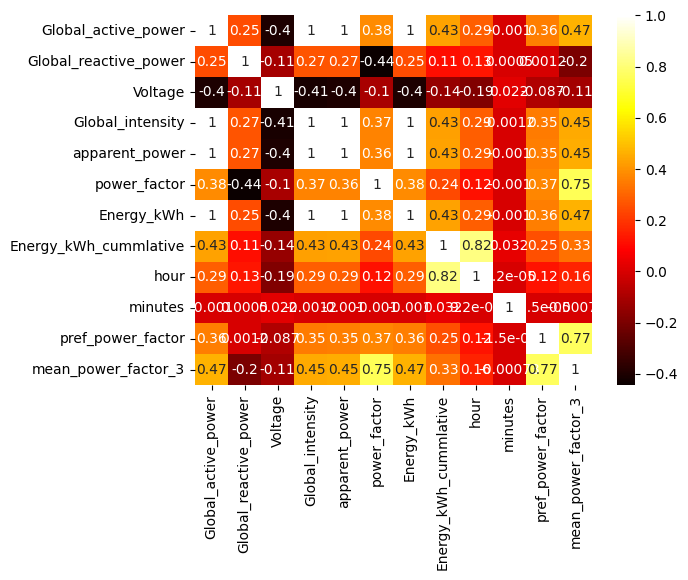

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='hot')
plt.show()

In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, f1_score, precision_score

model = RandomForestRegressor(n_estimators=150)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print(f"the mean absolute error of the model is: {mae}")

the mean absolute error of the model is: 0.005005382947576375


In [43]:
test = pd.DataFrame(test_data)

model.predict(test)

array([0.99687959])

In [44]:
import joblib

joblib.dump(model, "random_forest.pkl")

['random_forest.pkl']